In [2]:
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   # graphical
from sklearn.preprocessing import scale
import sklearn.linear_model as lm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [2]:
ab = pd.read_csv(r"D:\Auto.csv")

In [3]:
ab

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [4]:
ab.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

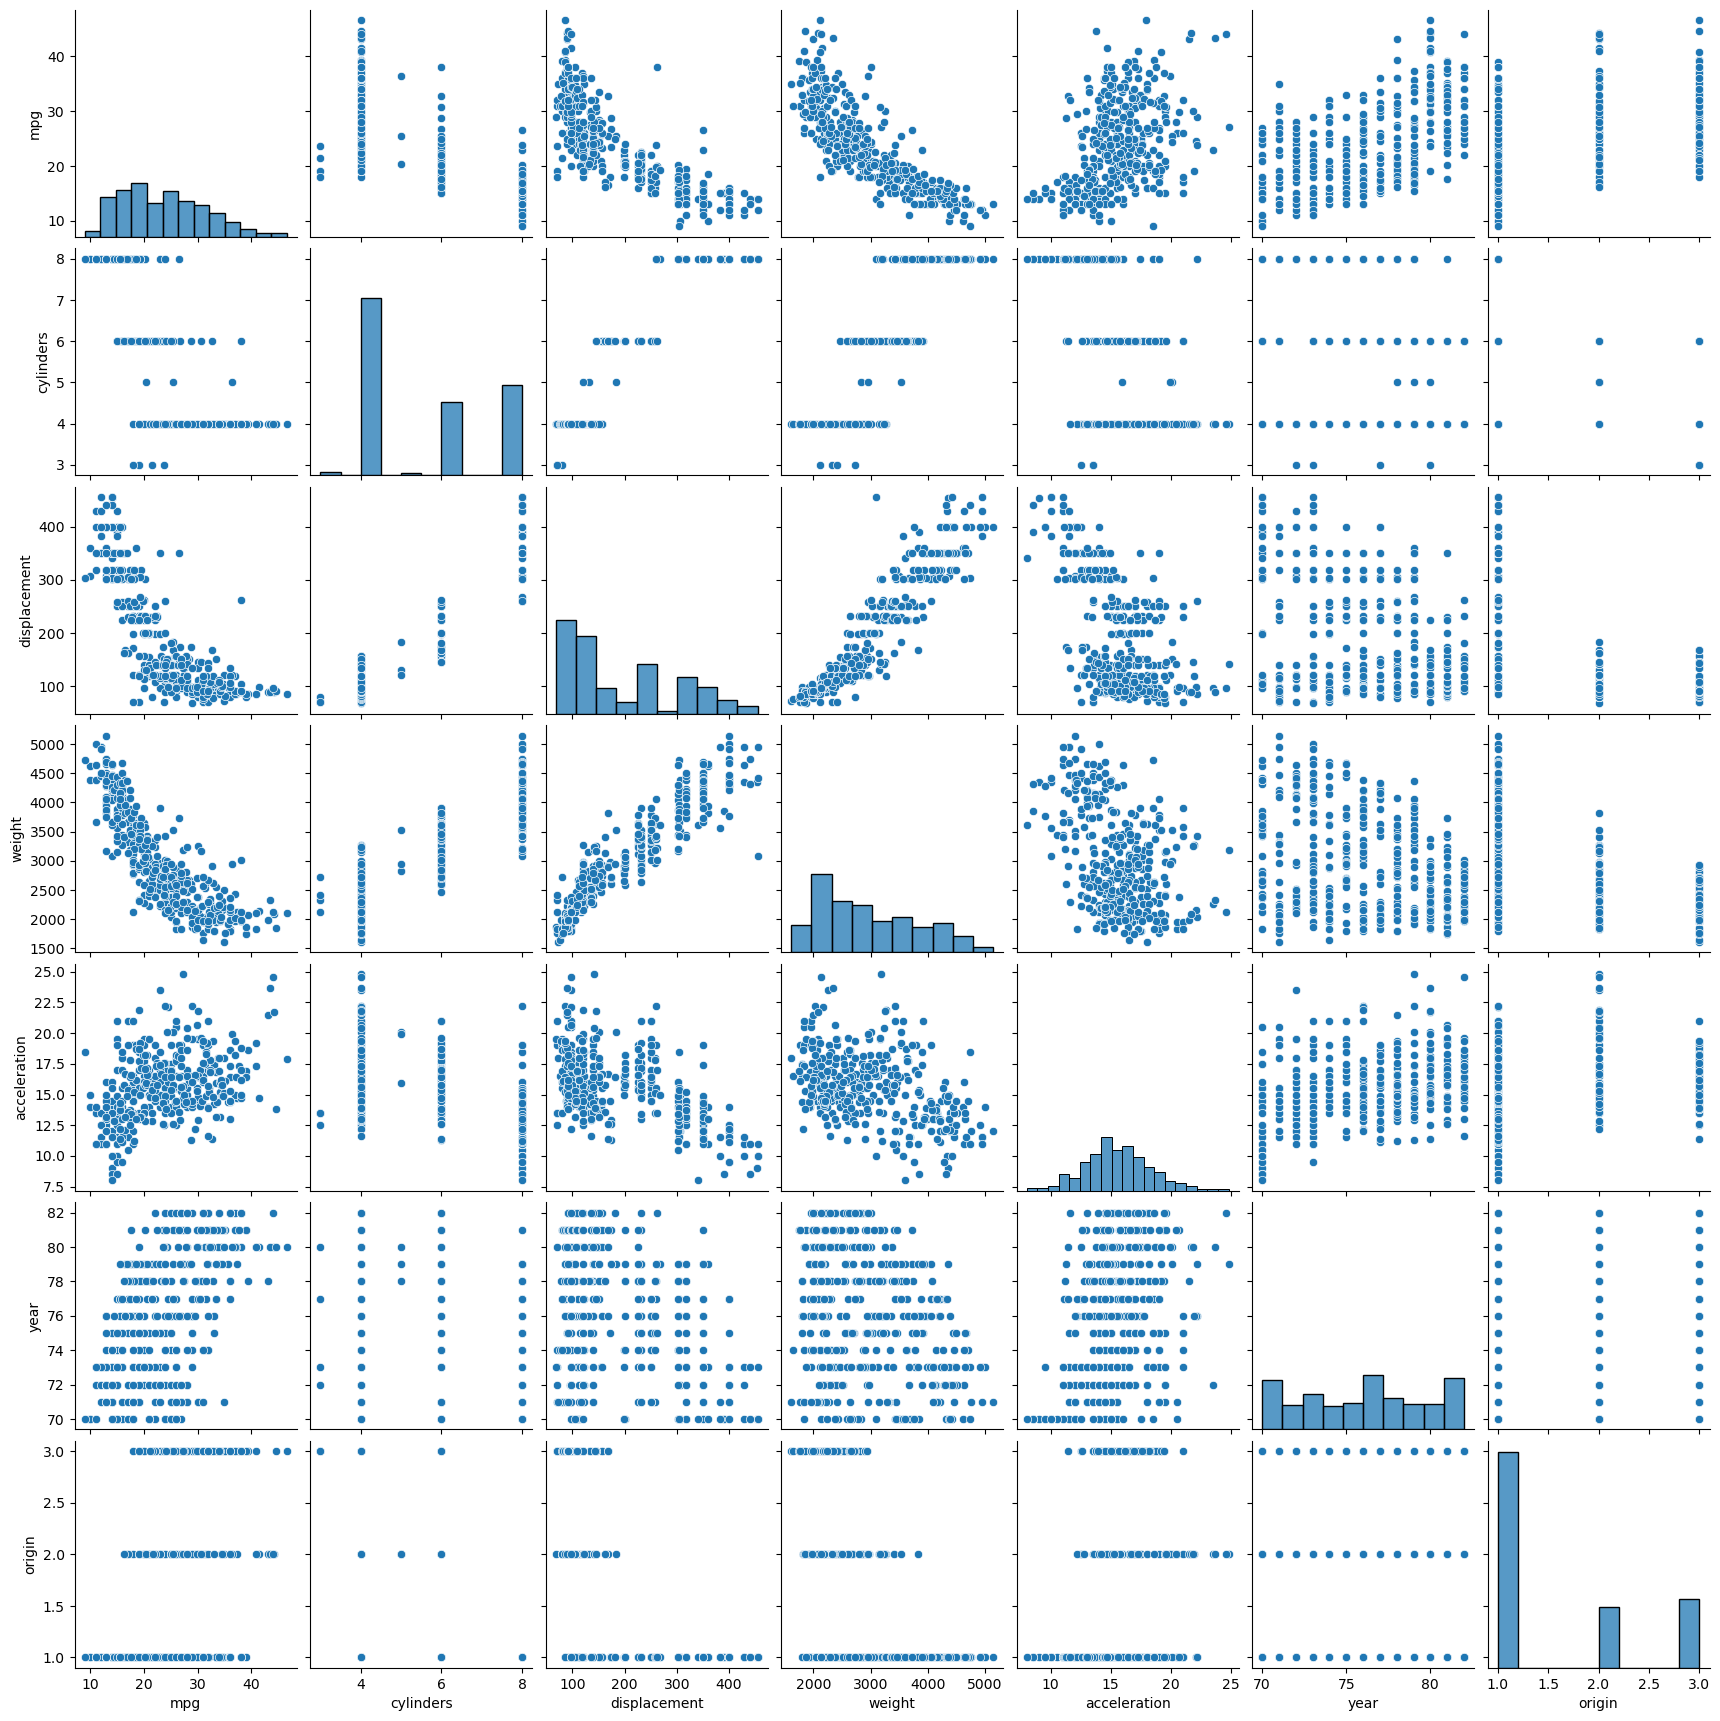

In [10]:
sns.pairplot(ab[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name']])

In [13]:
lm_fit1 = smf.ols("mpg~origin",ab).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     184.0
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.13e-34
Time:                        11:34:44   Log-Likelihood:                -1303.7
No. Observations:                 397   AIC:                             2611.
Df Residuals:                     395   BIC:                             2619.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.8623      0.716     20.760      0.000      13.455      16.270
origin         5.4967      0.405     13.564      0.000       4.700       6.293
==============================================================================
Omnibus:                       25.749   Durbin-Watson:                   0.825
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               29.291
Skew:                           0.663   Prob(JB):                     4.36e-07
Kurtosis:                       3.104   Cond. No.                         4.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
ab["origin"] = ab["origin"].replace({1: "US",
                                     2: "Japan",
                                     3: "Europe"})

In [16]:
ab

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,US,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,US,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,US,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,US,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,US,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,US,ford mustang gl
393,44.0,4,97.0,52,2130,24.6,82,Japan,vw pickup
394,32.0,4,135.0,84,2295,11.6,82,US,dodge rampage
395,28.0,4,120.0,79,2625,18.6,82,US,ford ranger


In [17]:
lm_fit1 = smf.ols("mpg~origin",ab).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     98.45
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.12e-35
Time:                        11:44:46   Log-Likelihood:                -1299.2
No. Observations:                 397   AIC:                             2604.
Df Residuals:                     394   BIC:                             2616.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          30.4506      0.721     42.246      0.000      29.034      31.868
origin[T.Japan]    -2.5592      1.052     -2.434      0.015      -4.627      -0.492
origin[T.US]      -10.3789      0.828    -12.540      0.000     -12.006      -8.752
==============================================================================
Omnibus:                       25.088   Durbin-Watson:                   0.753
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.611
Skew:                           0.657   Prob(JB):                     6.13e-07
Kurtosis:                       3.020   Cond. No.                         5.15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
originn_dummies = pd.get_dummies(ab ["origin"], columns=True)

In [22]:
ab.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

In [27]:
ab

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,US,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,US,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,US,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,US,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,US,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,US,ford mustang gl
393,44.0,4,97.0,52,2130,24.6,82,Japan,vw pickup
394,32.0,4,135.0,84,2295,11.6,82,US,dodge rampage
395,28.0,4,120.0,79,2625,18.6,82,US,ford ranger


In [28]:
ab = pd.concat([ab, originn_dummies], axis=1)

In [29]:
ab

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,Europe,Japan,US
0,18.0,8,307.0,130,3504,12.0,70,US,chevrolet chevelle malibu,False,False,True
1,15.0,8,350.0,165,3693,11.5,70,US,buick skylark 320,False,False,True
2,18.0,8,318.0,150,3436,11.0,70,US,plymouth satellite,False,False,True
3,16.0,8,304.0,150,3433,12.0,70,US,amc rebel sst,False,False,True
4,17.0,8,302.0,140,3449,10.5,70,US,ford torino,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,US,ford mustang gl,False,False,True
393,44.0,4,97.0,52,2130,24.6,82,Japan,vw pickup,False,True,False
394,32.0,4,135.0,84,2295,11.6,82,US,dodge rampage,False,False,True
395,28.0,4,120.0,79,2625,18.6,82,US,ford ranger,False,False,True


In [30]:
lm_fit1 = smf.ols("mpg~ Europe + Japan + US",ab).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     98.45
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.12e-35
Time:                        12:01:14   Log-Likelihood:                -1299.2
No. Observations:                 397   AIC:                             2604.
Df Residuals:                     394   BIC:                             2616.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         19.6035      0.282     69.543      0.000      19.049      20.158
Europe[T.True]    10.8472      0.582     18.624      0.000       9.702      11.992
Japan[T.True]      8.2880      0.610     13.577      0.000       7.088       9.488
US[T.True]         0.4683      0.403      1.163      0.246      -0.323       1.260
==============================================================================
Omnibus:                       25.088   Durbin-Watson:                   0.753
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.611
Skew:                           0.657   Prob(JB):                     6.13e-07
Kurtosis:                       3.020   Cond. No.                     1.80e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.83e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [31]:
lm_fit1 = smf.ols("mpg~ Europe + Japan",ab).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     98.45
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.12e-35
Time:                        12:04:07   Log-Likelihood:                -1299.2
No. Observations:                 397   AIC:                             2604.
Df Residuals:                     394   BIC:                             2616.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         20.0718      0.407     49.339      0.000      19.272      20.872
Europe[T.True]    10.3789      0.828     12.540      0.000       8.752      12.006
Japan[T.True]      7.8197      0.867      9.018      0.000       6.115       9.524
==============================================================================
Omnibus:                       25.088   Durbin-Watson:                   0.753
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.611
Skew:                           0.657   Prob(JB):                     6.13e-07
Kurtosis:                       3.020   Cond. No.                         3.16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
ab

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,Europe,Japan,US
0,18.0,8,307.0,130,3504,12.0,70,US,chevrolet chevelle malibu,False,False,True
1,15.0,8,350.0,165,3693,11.5,70,US,buick skylark 320,False,False,True
2,18.0,8,318.0,150,3436,11.0,70,US,plymouth satellite,False,False,True
3,16.0,8,304.0,150,3433,12.0,70,US,amc rebel sst,False,False,True
4,17.0,8,302.0,140,3449,10.5,70,US,ford torino,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,US,ford mustang gl,False,False,True
393,44.0,4,97.0,52,2130,24.6,82,Japan,vw pickup,False,True,False
394,32.0,4,135.0,84,2295,11.6,82,US,dodge rampage,False,False,True
395,28.0,4,120.0,79,2625,18.6,82,US,ford ranger,False,False,True


In [6]:
df = pd.read_csv(r"D:\Downloads\Credit.csv")

In [7]:
df

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance
0,14.891,3606,283,2,34,11,No,No,Yes,South,333
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.593,7075,514,4,71,11,No,No,No,West,580
3,148.924,9504,681,3,36,11,Yes,No,No,West,964
4,55.882,4897,357,2,68,16,No,No,Yes,South,331
...,...,...,...,...,...,...,...,...,...,...,...
395,12.096,4100,307,3,32,13,No,No,Yes,South,560
396,13.364,3838,296,5,65,17,No,No,No,East,480
397,57.872,4171,321,5,67,12,Yes,No,Yes,South,138
398,37.728,2525,192,1,44,13,No,No,Yes,South,0


In [8]:
df.columns

Index(['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Own',
       'Student', 'Married', 'Region', 'Balance'],
      dtype='object')

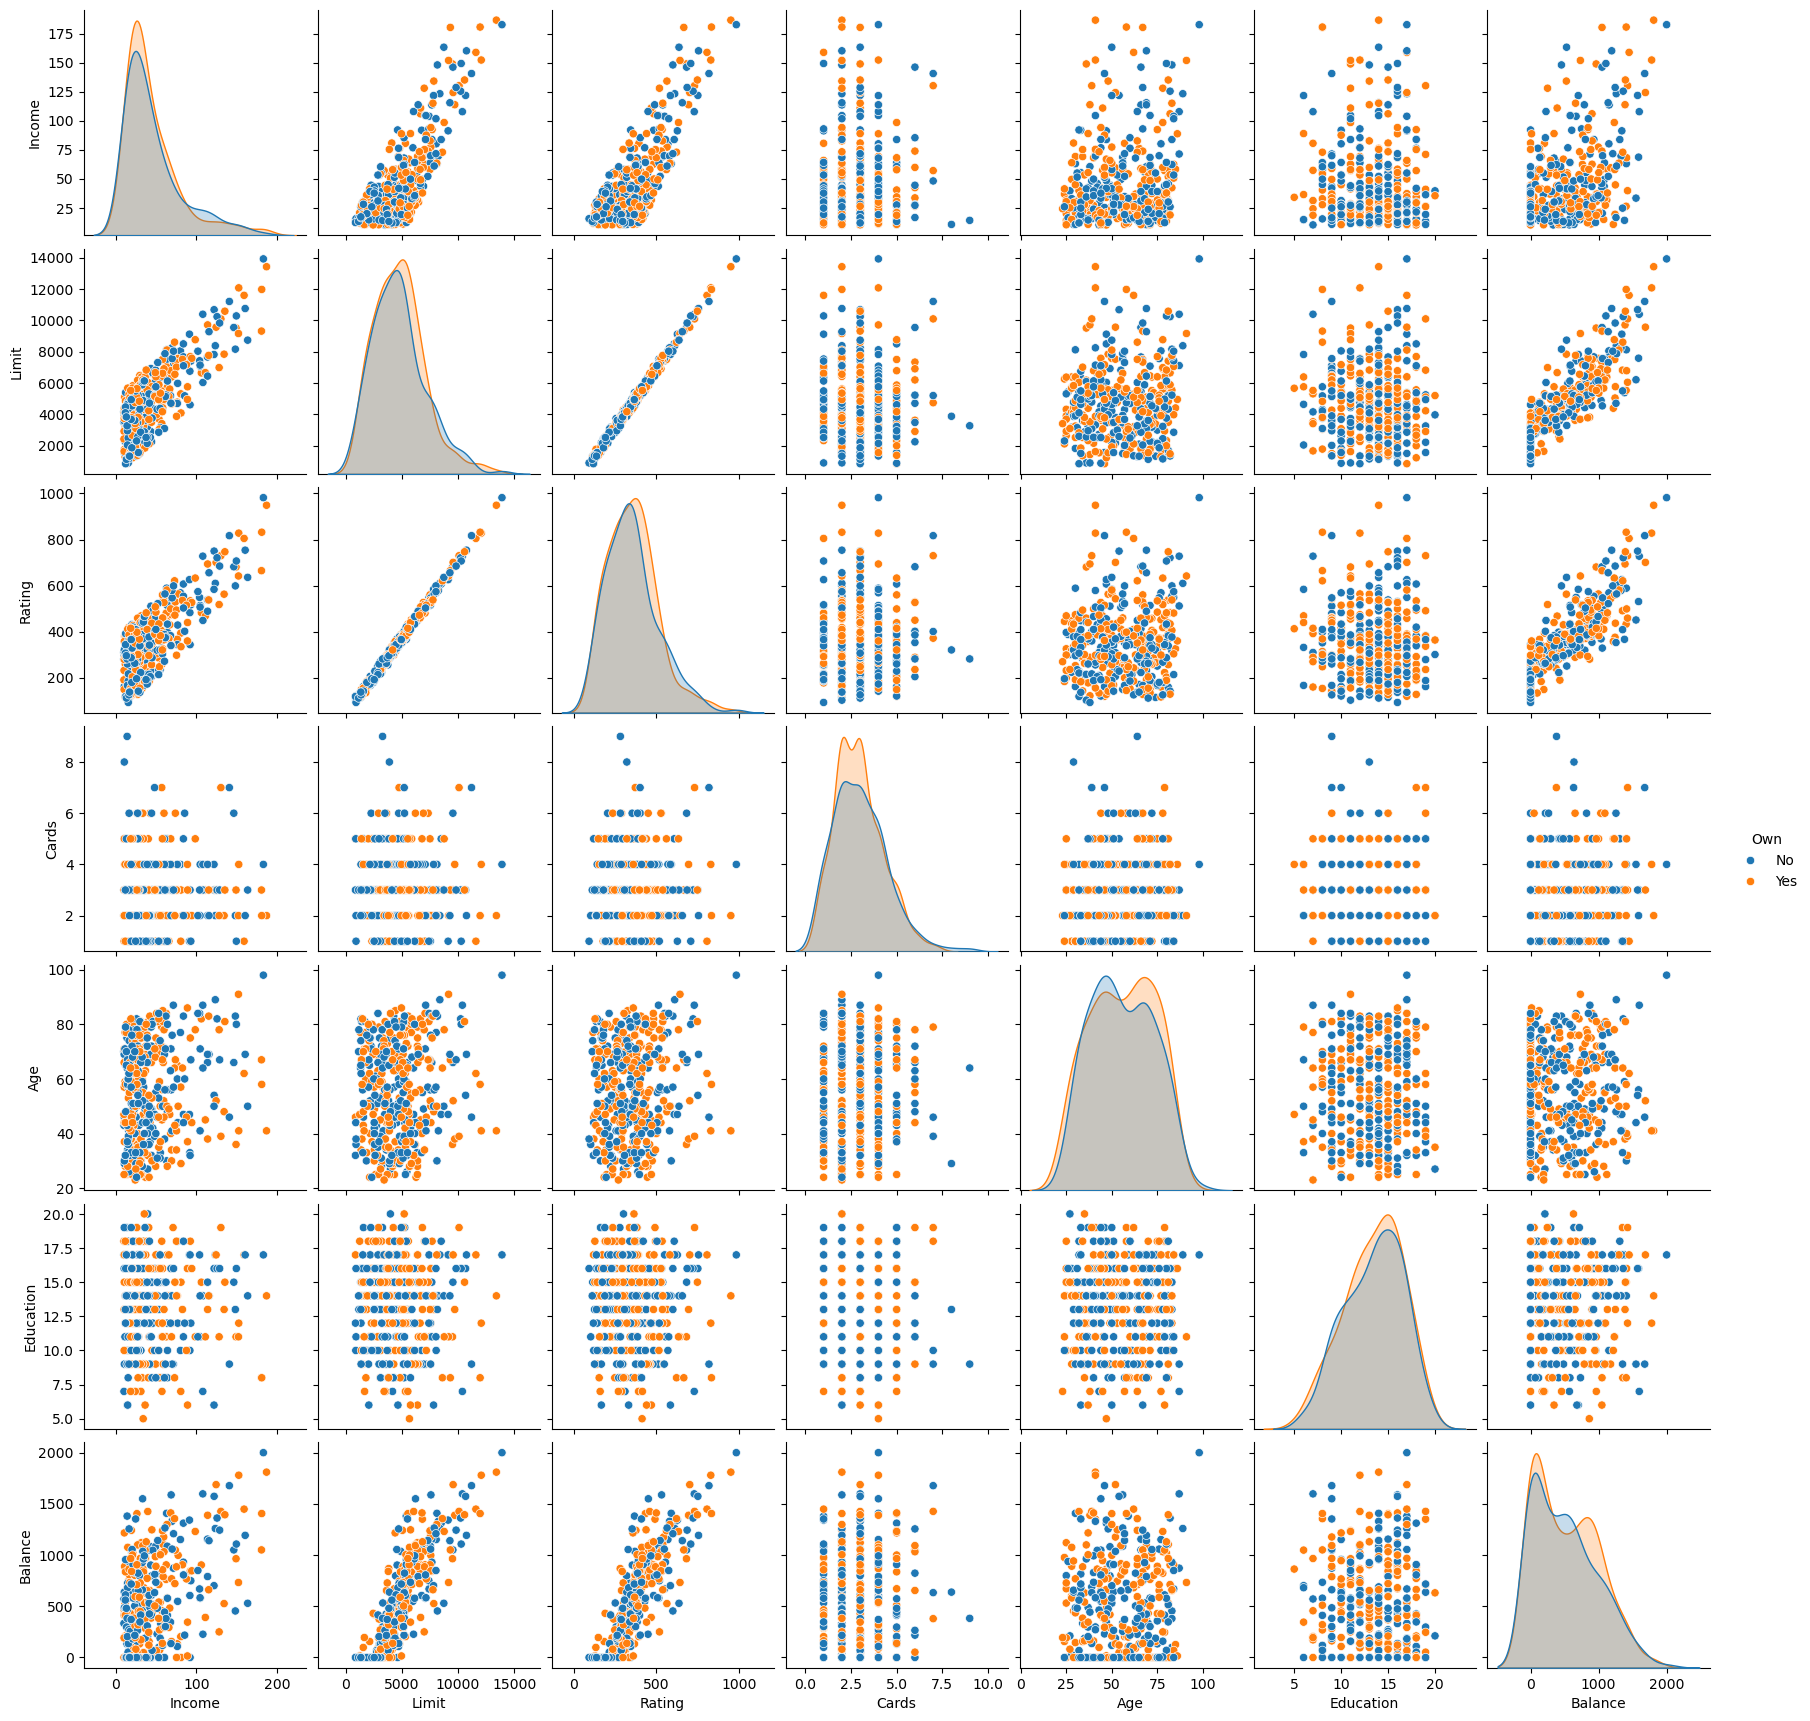

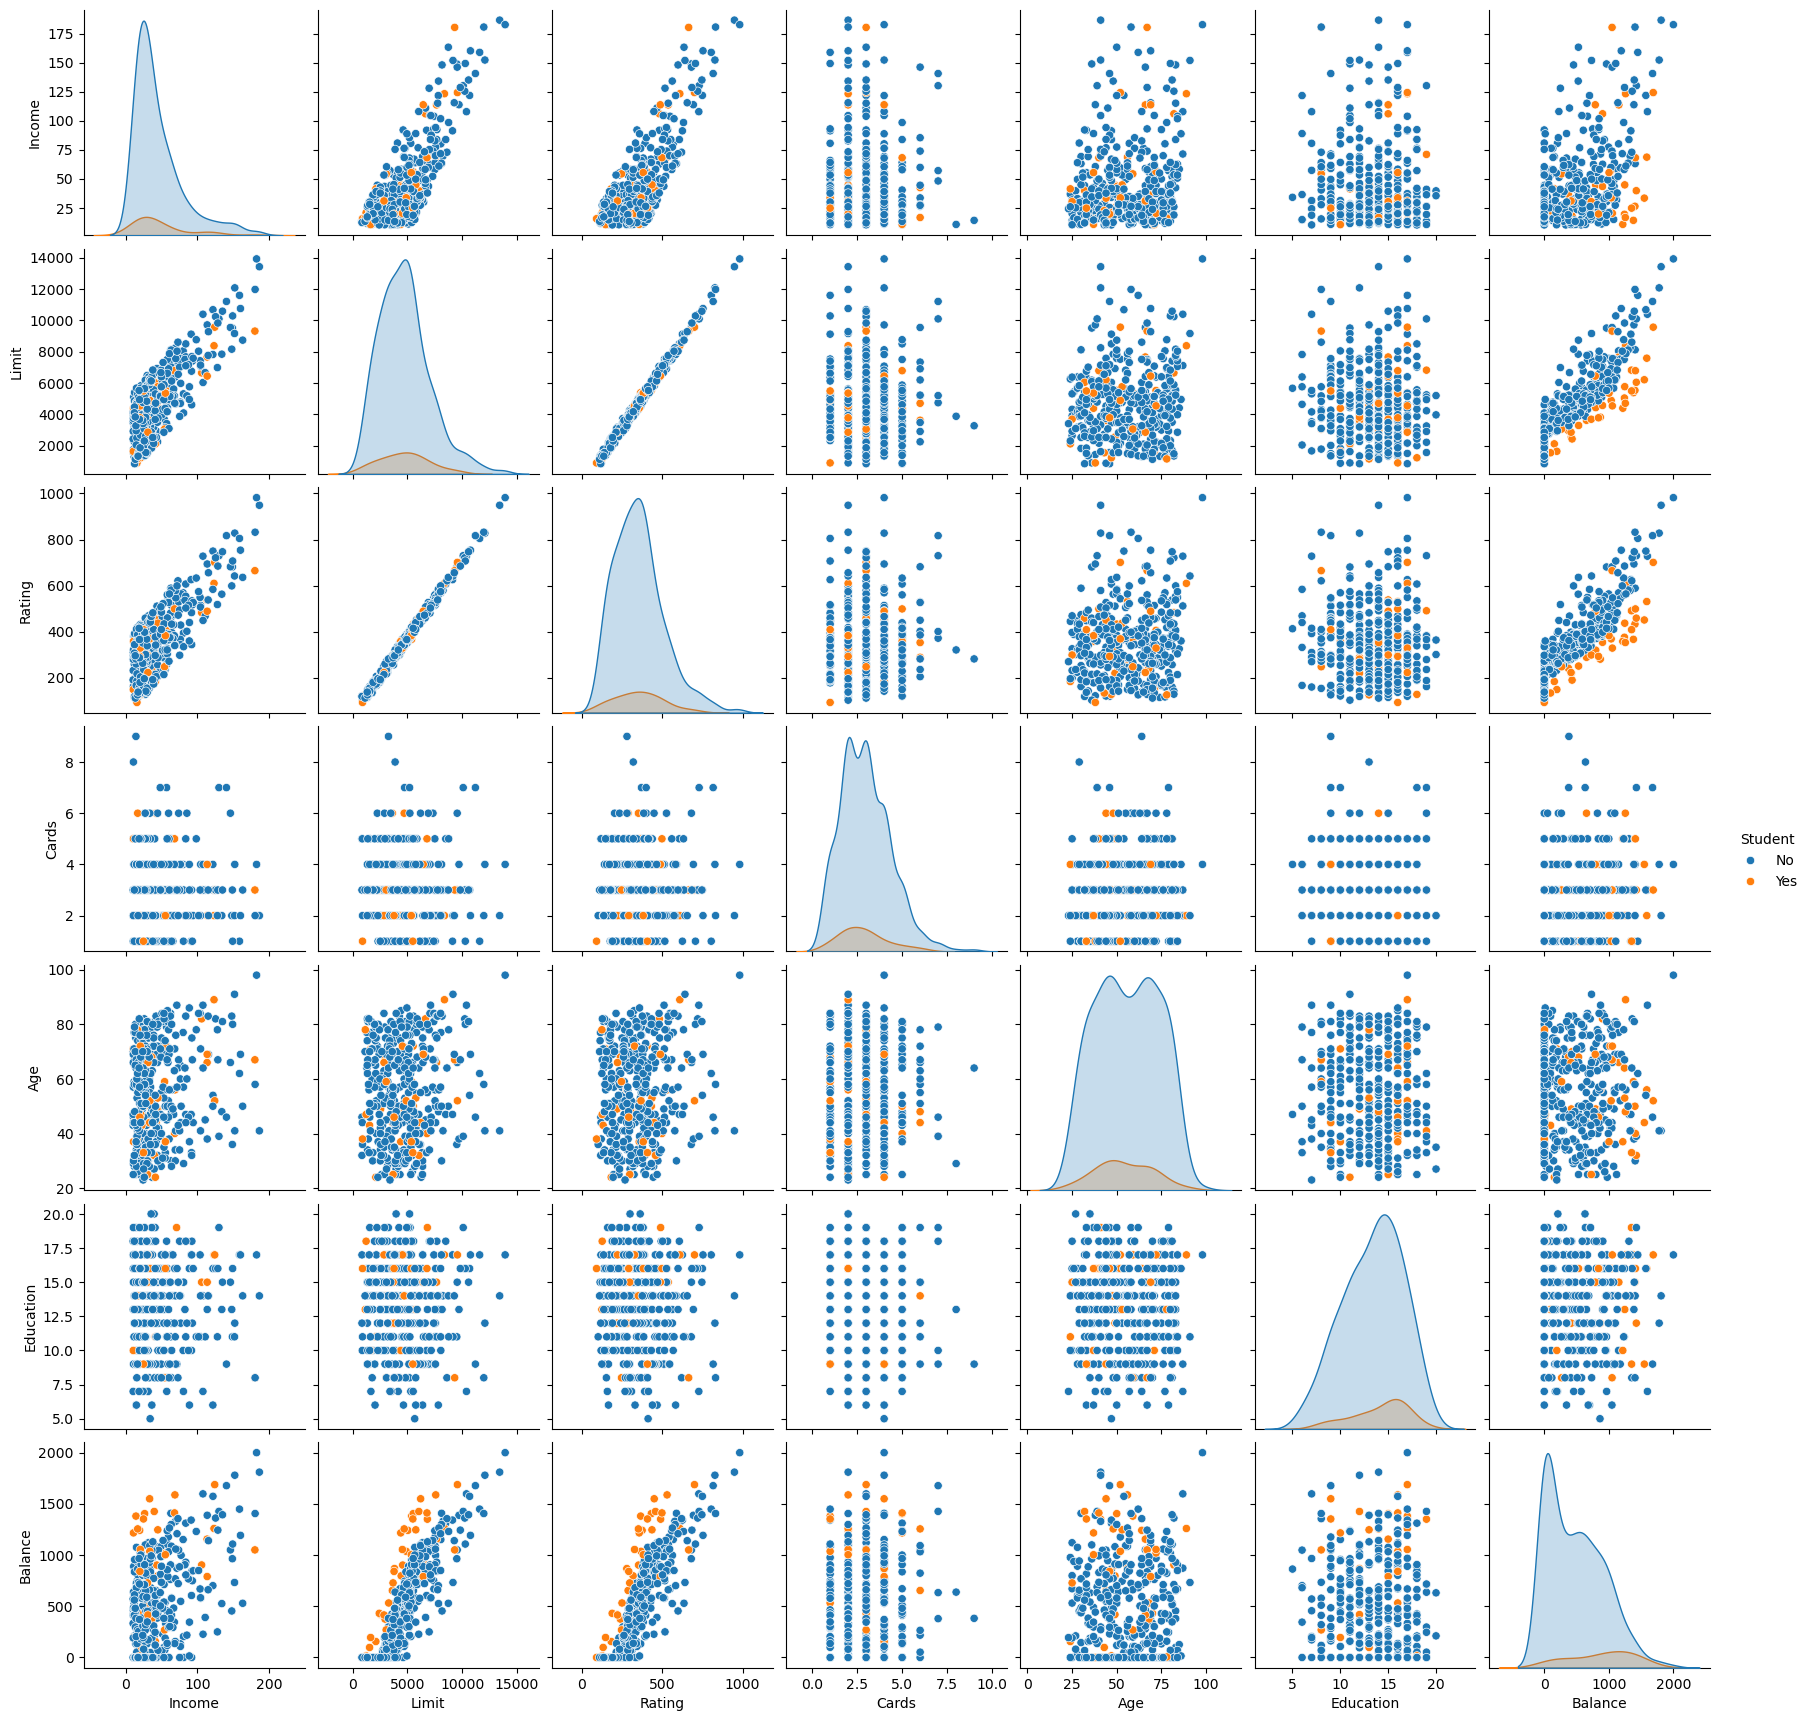

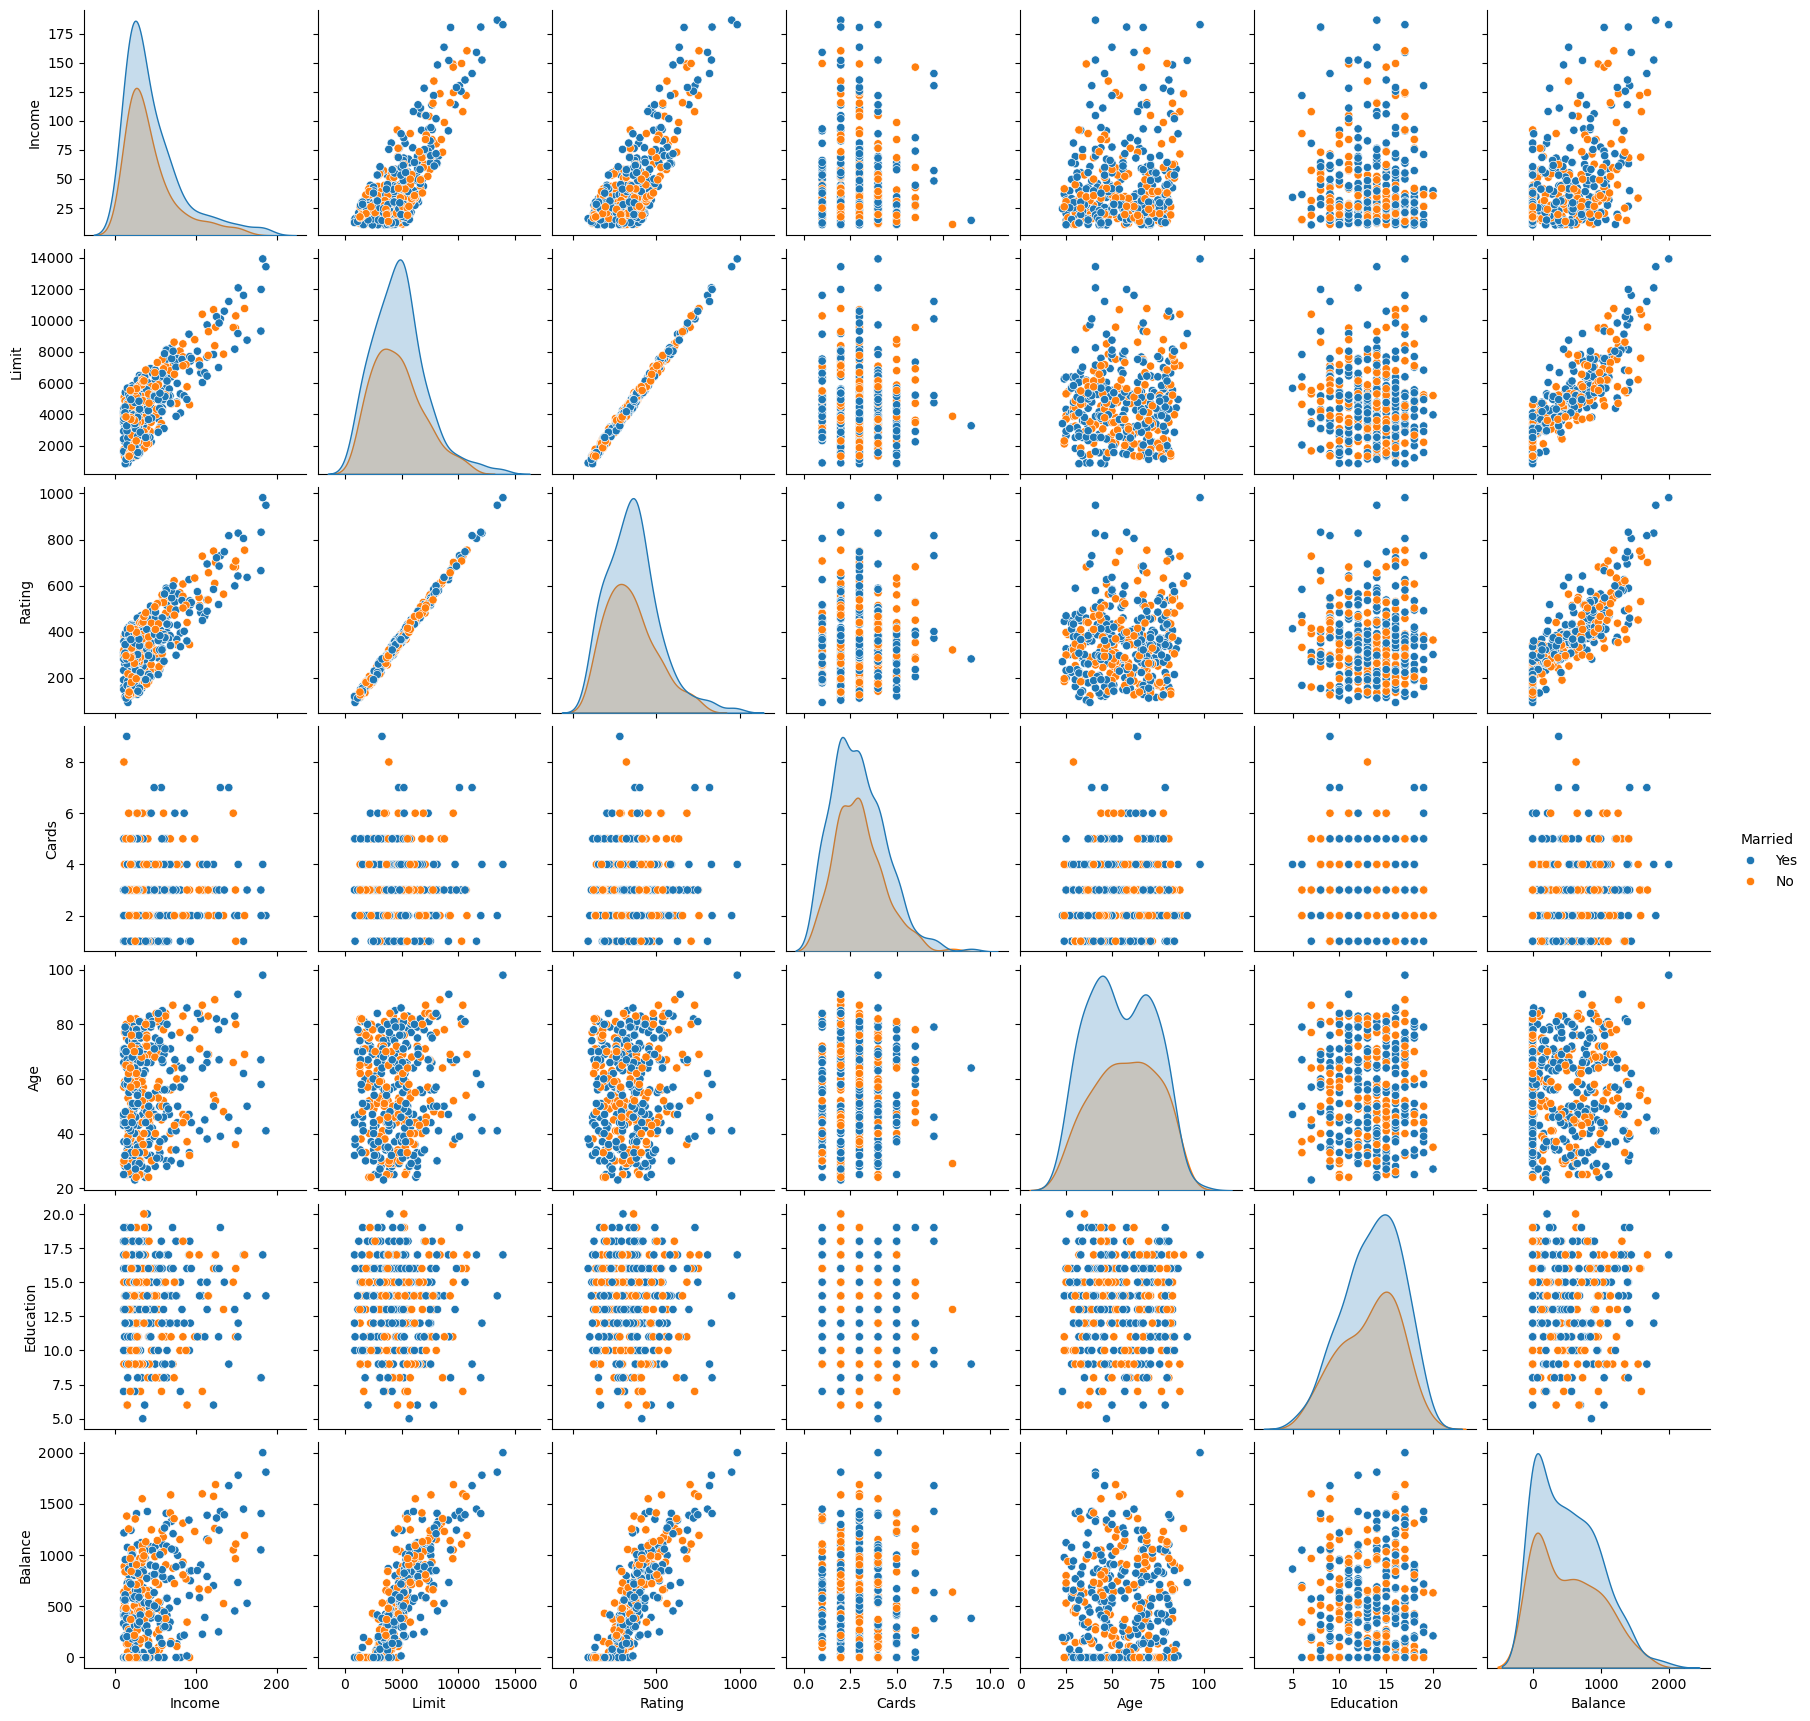

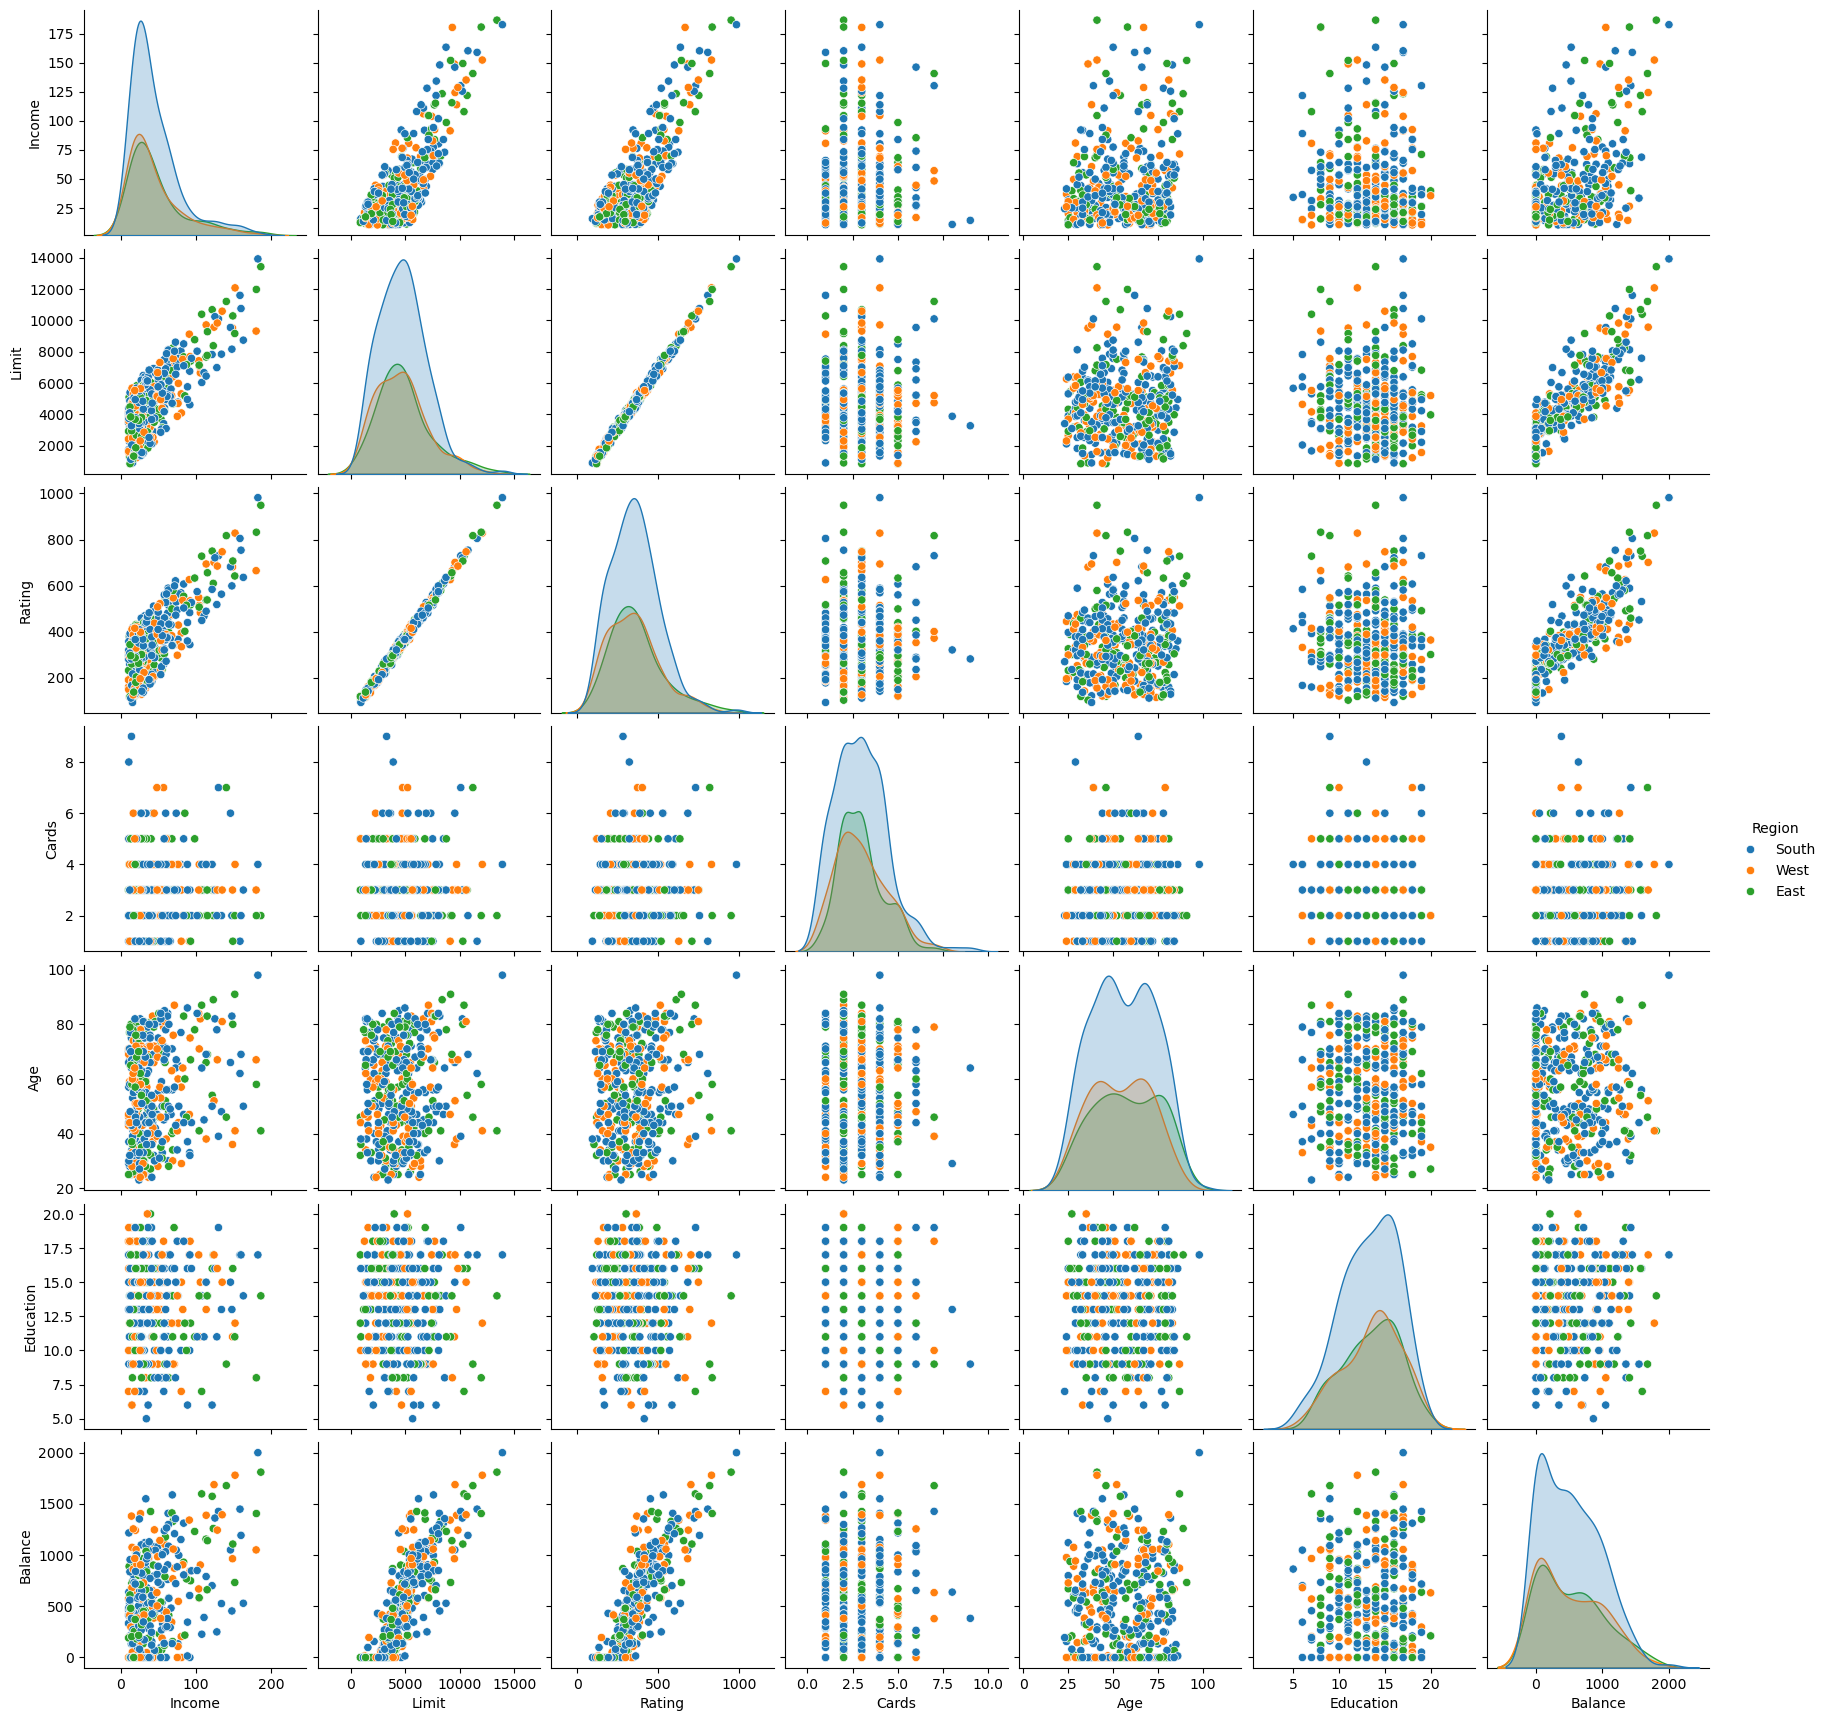

In [9]:
for col in ["Own", "Student", "Married", "Region"]:
    sns.pairplot(df, vars=['Income','Limit','Rating','Cards','Age','Education','Balance'],
                 hue=col)

In [10]:
lm_fit1 = smf.ols("Balance~Student + Limit + Rating + Cards + Age",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     374.3
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          3.44e-147
Time:                        12:29:06   Log-Likelihood:                -2669.5
No. Observations:                 400   AIC:                             5351.
Df Residuals:                     394   BIC:                             5375.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       -307.2888     47.327     -6.493      0.000    -400.333    -214.245
Student[T.Yes]   404.2638     32.277     12.525      0.000     340.806     467.721
Limit              0.1737      0.063      2.742      0.006       0.049       0.298
Rating            -0.0039      0.946     -0.004      0.997      -1.864       1.857
Cards             29.5156      8.424      3.504      0.001      12.955      46.077
Age               -2.1828      0.564     -3.873      0.000      -3.291      -1.075
==============================================================================
Omnibus:                       10.902   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.085
Skew:                          -0.403   Prob(JB):                      0.00392
Kurtosis:                       3.130   Cond. No.                     2.60e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.6e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Income     400 non-null    float64
 1   Limit      400 non-null    int64  
 2   Rating     400 non-null    int64  
 3   Cards      400 non-null    int64  
 4   Age        400 non-null    int64  
 5   Education  400 non-null    int64  
 6   Own        400 non-null    object 
 7   Student    400 non-null    object 
 8   Married    400 non-null    object 
 9   Region     400 non-null    object 
 10  Balance    400 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 34.5+ KB


In [12]:
lm_fit1 = smf.ols("Balance~Married",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.01281
Date:                Mon, 06 Apr 2026   Prob (F-statistic):              0.910
Time:                        12:29:06   Log-Likelihood:                -3019.3
No. Observations:                 400   AIC:                             6043.
Df Residuals:                     398   BIC:                             6051.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        523.2903     36.974     14.153      0.000     450.601     595.980
Married[T.Yes]    -5.3475     47.244     -0.113      0.910     -98.227      87.532
==============================================================================
Omnibus:                       28.640   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.347
Skew:                           0.582   Prob(JB):                     1.15e-06
Kurtosis:                       2.464   Cond. No.                         2.97
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
lm_fit1 = smf.ols("Balance~Student",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     28.62
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.49e-07
Time:                        12:29:06   Log-Likelihood:                -3005.5
No. Observations:                 400   AIC:                             6015.
Df Residuals:                     398   BIC:                             6023.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        480.3694     23.434     20.499      0.000     434.300     526.439
Student[T.Yes]   396.4556     74.104      5.350      0.000     250.771     542.140
==============================================================================
Omnibus:                       20.866   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.920
Skew:                           0.544   Prob(JB):                     1.74e-05
Kurtosis:                       2.637   Cond. No.                         3.37
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
og =  pd.get_dummies(df, columns=["Student","Married"])

In [15]:
og.columns

Index(['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Own',
       'Region', 'Balance', 'Student_No', 'Student_Yes', 'Married_No',
       'Married_Yes'],
      dtype='object')

In [16]:
og

,Income,Limit,Rating,Cards,Age,Education,Own,Region,Balance,Student_No,Student_Yes,Married_No,Married_Yes
0,14.891,3606,283,2,34,11,No,South,333,True,False,False,True
1,106.025,6645,483,3,82,15,Yes,West,903,False,True,False,True
2,104.593,7075,514,4,71,11,No,West,580,True,False,True,False
3,148.924,9504,681,3,36,11,Yes,West,964,True,False,True,False
4,55.882,4897,357,2,68,16,No,South,331,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,12.096,4100,307,3,32,13,No,South,560,True,False,False,True
396,13.364,3838,296,5,65,17,No,East,480,True,False,True,False
397,57.872,4171,321,5,67,12,Yes,South,138,True,False,False,True
398,37.728,2525,192,1,44,13,No,South,0,True,False,False,True


In [17]:
lm_fit1 = smf.ols("Balance~ Married_No + Married_Yes ",data = og).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                  0.006390
Date:                Mon, 06 Apr 2026   Prob (F-statistic):              0.994
Time:                        12:29:06   Log-Likelihood:                -3019.3
No. Observations:                 400   AIC:                             6045.
Df Residuals:                     397   BIC:                             6057.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             347.0777     15.768     22.012      0.000     316.079     378.077
Married_No[T.True]    176.2126     26.561      6.634      0.000     123.995     228.430
Married_Yes[T.True]   170.8651     23.187      7.369      0.000     125.280     216.451
==============================================================================
Omnibus:                       28.640   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.347
Skew:                           0.582   Prob(JB):                     1.15e-06
Kurtosis:                       2.464   Cond. No.                     1.36e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.34e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [18]:
lm_fit1 = smf.ols("Balance~ Student_No + Student_Yes ",data = og).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     14.28
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.03e-06
Time:                        12:29:06   Log-Likelihood:                -3005.5
No. Observations:                 400   AIC:                             6017.
Df Residuals:                     397   BIC:                             6029.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             452.3981     24.733     18.292      0.000     403.775     501.021
Student_No[T.True]     27.9713     28.199      0.992      0.322     -27.468      83.410
Student_Yes[T.True]   424.4269     47.574      8.921      0.000     330.898     517.955
==============================================================================
Omnibus:                       20.866   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.920
Skew:                           0.544   Prob(JB):                     1.74e-05
Kurtosis:                       2.637   Cond. No.                     1.13e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 5.82e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [19]:
lm_fit1 = smf.ols("Balance~ Income ",data = og).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     109.0
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.03e-22
Time:                        12:29:06   Log-Likelihood:                -2970.9
No. Observations:                 400   AIC:                             5946.
Df Residuals:                     398   BIC:                             5954.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    246.5148     33.199      7.425      0.000     181.247     311.783
Income         6.0484      0.579     10.440      0.000       4.909       7.187
==============================================================================
Omnibus:                       42.505   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.975
Skew:                           0.384   Prob(JB):                     2.79e-05
Kurtosis:                       2.182   Cond. No.                         93.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
lm_fit1 = smf.ols("Balance~ Income + Student_No + Student_Yes ",data = og).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     76.22
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           9.64e-29
Time:                        12:29:06   Log-Likelihood:                -2954.4
No. Observations:                 400   AIC:                             5915.
Df Residuals:                     397   BIC:                             5927.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             268.3188     27.693      9.689      0.000     213.875     322.763
Student_No[T.True]    -57.1759     26.050     -2.195      0.029    -108.389      -5.962
Student_Yes[T.True]   325.4947     42.867      7.593      0.000     241.220     409.770
Income                  5.9843      0.557     10.751      0.000       4.890       7.079
==============================================================================
Omnibus:                      119.719   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.617
Skew:                           0.252   Prob(JB):                     7.44e-06
Kurtosis:                       1.922   Cond. No.                     4.72e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 5.9e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [27]:
lm_fit1 = smf.ols("Balance~ Income + Rating + Limit + Cards + Age +  Married_No + Married_Yes + Student_Yes ",data = og).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     1182.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          4.63e-259
Time:                        12:30:21   Log-Likelihood:                -2400.2
No. Observations:                 400   AIC:                             4816.
Df Residuals:                     392   BIC:                             4848.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            -328.5283     16.580    -19.814      0.000    -361.126    -295.931
Married_No[T.True]   -160.4295      9.964    -16.100      0.000    -180.020    -140.839
Married_Yes[T.True]  -168.0988      9.523    -17.652      0.000    -186.822    -149.376
Student_Yes[T.True]   424.5123     16.584     25.598      0.000     391.908     457.117
Income                 -7.7903      0.234    -33.344      0.000      -8.250      -7.331
Rating                  1.1271      0.487      2.312      0.021       0.169       2.085
Limit                   0.1913      0.033      5.875      0.000       0.127       0.255
Cards                  18.0166      4.329      4.162      0.000       9.506      26.527
Age                    -0.6425      0.293     -2.193      0.029      -1.219      -0.066
==============================================================================
Omnibus:                       34.636   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               41.361
Skew:                           0.778   Prob(JB):                     1.04e-09
Kurtosis:                       3.247   Cond. No.                     6.30e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.81e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [22]:
og.columns

Index(['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Own',
       'Region', 'Balance', 'Student_No', 'Student_Yes', 'Married_No',
       'Married_Yes'],
      dtype='object')